# STEMNIST数据训练与识别

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from spikingjelly.activation_based import functional

In [2]:
# 固定随机种子
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. 参数定义

In [ ]:
EXPERIMENT_NAME = "(model_v2_with_lif)T60_dropout_0.1_batchsize_64_lr_0.002_tau_10.0"

BATCH_SIZE = 64
TIME_STEPS = 60
DROPOUT_RATE = 0.1
TAU = 10.0

LEARNING_RATE = 0.002
MIN_LEARNING_RATE = 1e-5
WARMUP_EPOCHS = 10
NUM_EPOCHS = 150

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. 数据

In [4]:
from data_utils_slow import make_dataloaders

In [5]:
train_loader, val_loader, test_loader = make_dataloaders(time_steps=TIME_STEPS, batch_size=BATCH_SIZE)

开始预读取 7700 个样本……
已读取 500/7700
已读取 1000/7700
已读取 1500/7700
已读取 2000/7700
已读取 2500/7700
已读取 3000/7700
已读取 3500/7700
已读取 4000/7700
已读取 4500/7700
已读取 5000/7700
已读取 5500/7700
已读取 6000/7700
已读取 6500/7700
已读取 7000/7700
已读取 7500/7700
预读取完成： torch.Size([7700, 120, 1, 16, 16]) torch.uint8
训练集压力基线：min=81.0, median=81.0, max=81.0


In [6]:
print(f"Train loader length: {len(train_loader)}")
print(f"Validation loader length: {len(val_loader)}")
print(f"Test loader length: {len(test_loader)}")

Train loader length: 77
Validation loader length: 20
Test loader length: 25


In [7]:
# 检查单元
batch = next(iter(train_loader))
inputs, labels = batch[:2]

print("DataLoader 输入形状：", inputs.shape)
print("标签形状：", labels.shape)

expected_shape = (
    inputs.shape[0],
    TIME_STEPS,
    1,
    16,
    16,
)

assert tuple(inputs.shape) == expected_shape, (
    f"输入形状错误：期望 {expected_shape}，"
    f"实际为 {tuple(inputs.shape)}"
)

snn_inputs = inputs.permute(
    1, 0, 2, 3, 4
).contiguous()

print("SNN 输入形状：", snn_inputs.shape)

assert snn_inputs.shape[0] == TIME_STEPS

DataLoader 输入形状： torch.Size([64, 120, 1, 16, 16])
标签形状： torch.Size([64])
SNN 输入形状： torch.Size([120, 64, 1, 16, 16])


## 3. 模型

### 3.1 简单模型

In [8]:
# from model_v1 import ConvSNN
# model = ConvSNN(num_classes=35, dropout=DROPOUT_RATE, tau=10.0, logit_scale=10.0).to(DEVICE)

### 3.2 复杂模型

In [9]:
from model_v2_with_lif import ConvSNN

model = ConvSNN(
    num_classes=35,
    dropout=DROPOUT_RATE,
    tau=TAU,
    logit_scale=1.0,
).to(DEVICE)

In [10]:
model.parameter_count()

25683

## 4. 损失优化

**warmup + 学习率衰退：**

epoch 1：约 1e-4    \
前 5 epoch：逐渐增加到 1e-3 \
剩余 epoch：从 1e-3 余弦下降到 1e-5 

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=MIN_LEARNING_RATE,
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        warmup_scheduler,
        cosine_scheduler,
    ],
    milestones=[
        WARMUP_EPOCHS,
    ],
)

## 5.训练

In [12]:
from function_utils import train_epoch, validate_epoch, train_model

In [13]:
# train_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch=1)

In [14]:
# validate_epoch(
#     model=model,
#     val_loader=val_loader,
#     criterion=criterion,
#     device=DEVICE,
#     epoch=1
# )

In [15]:
history = train_model(model, 
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            num_epochs=NUM_EPOCHS,
            save_path=f"../outputs/{EXPERIMENT_NAME}/best_model.pt",
            scheduler=scheduler
)

Train Epoch 1:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.004845 | lif2=0.038143 | output=0.118707

Epoch 001/100 | Train loss: 3.5516 | Train accuracy: 0.0386 | Val loss: 3.5656 | Val accuracy: 0.0308 | LR: 0.0005
✓ 保存最佳模型：../outputs/(model_v2_with_lif)T120_dropout_0.1_batchsize_64_lr_0.005_tau_10.0/best_model.pt
  epoch=1, val_accuracy=0.0308


Train Epoch 2:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 2:   0%|          | 0/20 [00:00<?, ?it/s]

...

Val Epoch 99:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.138790 | lif2=0.023439 | output=0.133336

Epoch 099/100 | Train loss: 0.9895 | Train accuracy: 0.7595 | Val loss: 0.8985 | Val accuracy: 0.8117 | LR: 1.5455e-05


Train Epoch 100:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 100:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.139809 | lif2=0.022893 | output=0.133046

Epoch 100/100 | Train loss: 0.9968 | Train accuracy: 0.7512 | Val loss: 0.8975 | Val accuracy: 0.8166 | LR: 1.13641e-05

训练完成
最佳 epoch：93
最佳验证集准确率：0.8239
最佳模型路径：../outputs/(model_v2_with_lif)T120_dropout_0.1_batchsize_64_lr_0.005_tau_10.0/best_model.pt


## 6. 结果可视化与数据保存

In [16]:
from function_utils import plot_training_history

训练曲线已保存：/root/autodl-tmp/SNN_for_STEMNIST/first_stage/outputs/(model_v2_with_lif)T120_dropout_0.1_batchsize_64_lr_0.005_tau_10.0/training_history.png


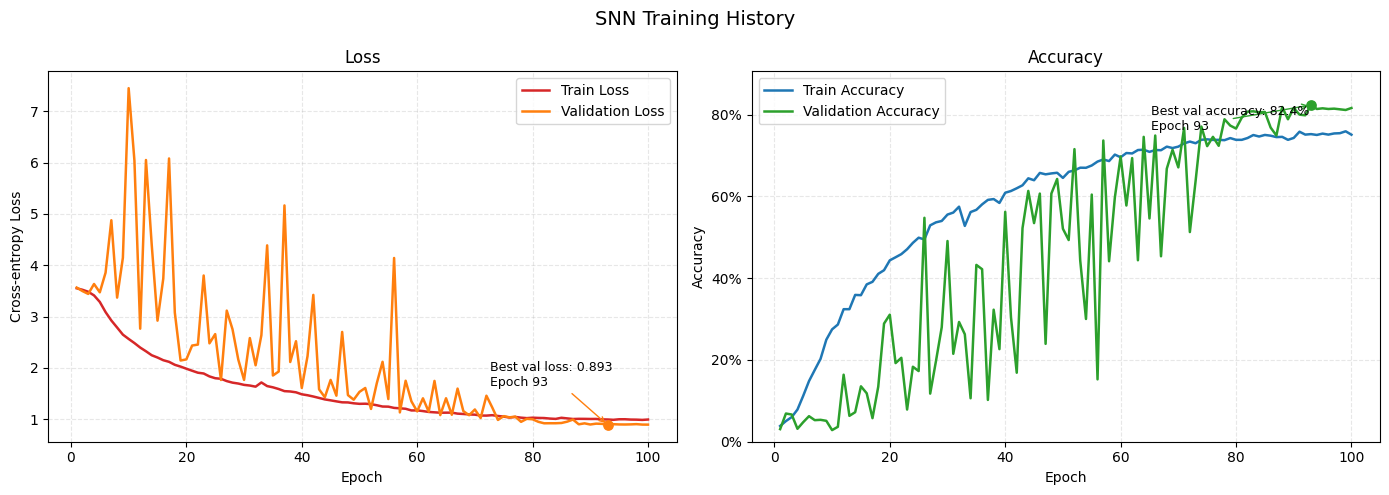

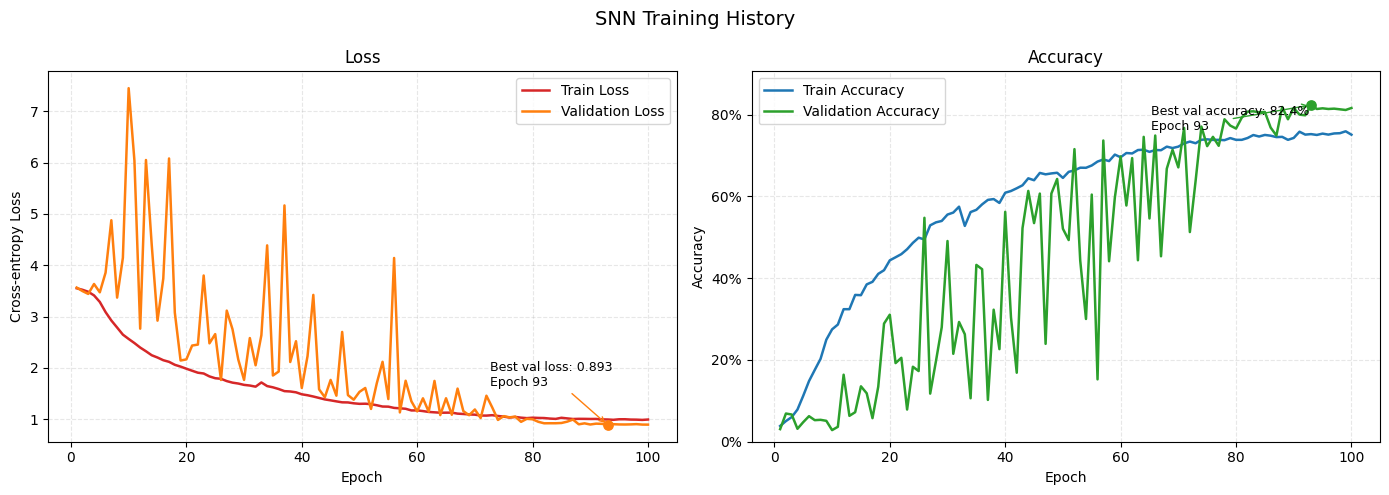

In [17]:
plot_training_history(
    history,
    save_path=f"../outputs/{EXPERIMENT_NAME}/training_history.png",
)

In [18]:
# 保存history为csv文件
import pandas as pd
history_df = pd.DataFrame(history)
history_df.to_csv(f"../outputs/{EXPERIMENT_NAME}/training_history.csv", index=False)

## 7. 测试集准确率

In [19]:
# 测试集准确率
test_result = validate_epoch(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test accuracy: {test_result['accuracy']:.4f}")

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Test accuracy: 0.8182
